# 03 — Exploratory Data Analysis

**Source:** `data/processed/olist_master_dataset.csv`

| Chart | Metric |
|---|---|
| Donut | Overall On-Time Delivery Rate |
| Bar | Revenue by Customer State |
| Horizontal Bar | Avg Review Score by Product Category |
| Horizontal Bar | On-Time Delivery Rate by Product Category |

## 1 — Setup

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

BG = '#1C1C2E'
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': BG,
    'axes.facecolor': BG, 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'text.color': 'white', 'axes.titlecolor': 'white',
    'axes.edgecolor': '#444',
})

PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().resolve().name == 'notebooks'
    else Path.cwd().resolve()
)
PROC    = PROJECT_ROOT / 'data' / 'processed'
INSIGHTS = PROJECT_ROOT / 'insights'
INSIGHTS.mkdir(exist_ok=True)

df = pd.read_csv(
    PROC / 'olist_master_dataset.csv',
    parse_dates=['order_purchase_timestamp',
                 'order_delivered_customer_date',
                 'order_estimated_delivery_date']
)
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
df.head(3)

Loaded 98,207 rows × 36 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,review_score,review_comment_message,delivery_time_days,delivery_delay_days,is_late,order_year_month,order_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,9350.0,maua,SP,4.0,"Não testei o produto ainda, mas ele veio corre...",8.0,-8.0,False,2017-10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,31570.0,belo horizonte,SP,4.0,Muito bom o produto.,13.0,-6.0,False,2018-07,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,14840.0,guariba,SP,5.0,No Comment,9.0,-18.0,False,2018-08,2018


## 2 — Overall On-Time Delivery Rate

Total delivered orders : 98,207
On-Time Delivery Rate  : 93.35%
Late Delivery Rate     : 6.65%


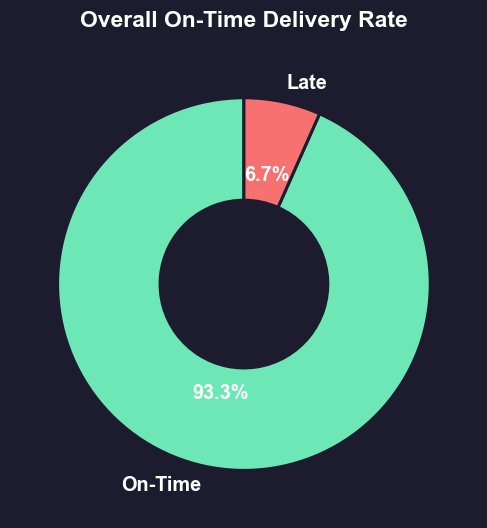

In [2]:
delivered     = df[df['is_late'].notna()].copy()
on_time_rate  = (delivered['is_late'] == False).sum() / len(delivered)
late_rate     = 1 - on_time_rate

print(f'Total delivered orders : {len(delivered):,}')
print(f'On-Time Delivery Rate  : {on_time_rate:.2%}')
print(f'Late Delivery Rate     : {late_rate:.2%}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(
    [on_time_rate, late_rate],
    labels=['On-Time', 'Late'],
    colors=['#6EE7B7', '#F87171'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': BG, 'linewidth': 2},
    textprops={'color': 'white', 'fontsize': 13, 'fontweight': 'bold'},
)
ax.set_title('Overall On-Time Delivery Rate', fontsize=15, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig(INSIGHTS / 'eda_01_ontime_rate.png', bbox_inches='tight', facecolor=BG)
plt.show()

> **Business Insight:** 93.35% of delivered orders arrive on time. Late orders disproportionately impact customer satisfaction — quantified in notebook 04.

## 3 — Revenue by Customer State

State  Total Revenue (BRL)
   SP           5163867.22
   RJ           1811623.42
   MG           1573508.20
   RS            742559.78
   PR            676883.06
   SC            518578.28
   BA            507108.83
   DF            300886.45
   GO            287870.46
   ES            273532.13
   PE            261739.94
   CE            226264.06
   PA            178821.12
   MT            156313.53
   MA            119291.62
   MS            116754.65
   PB            114874.10
   PI             86660.09
   RN             83034.98
   AL             80314.81
   SE             58920.85
   TO             49407.99
   RO             46031.64
   AM             22356.84
   AC             15982.95
   AP             13474.30
   RR              7739.44


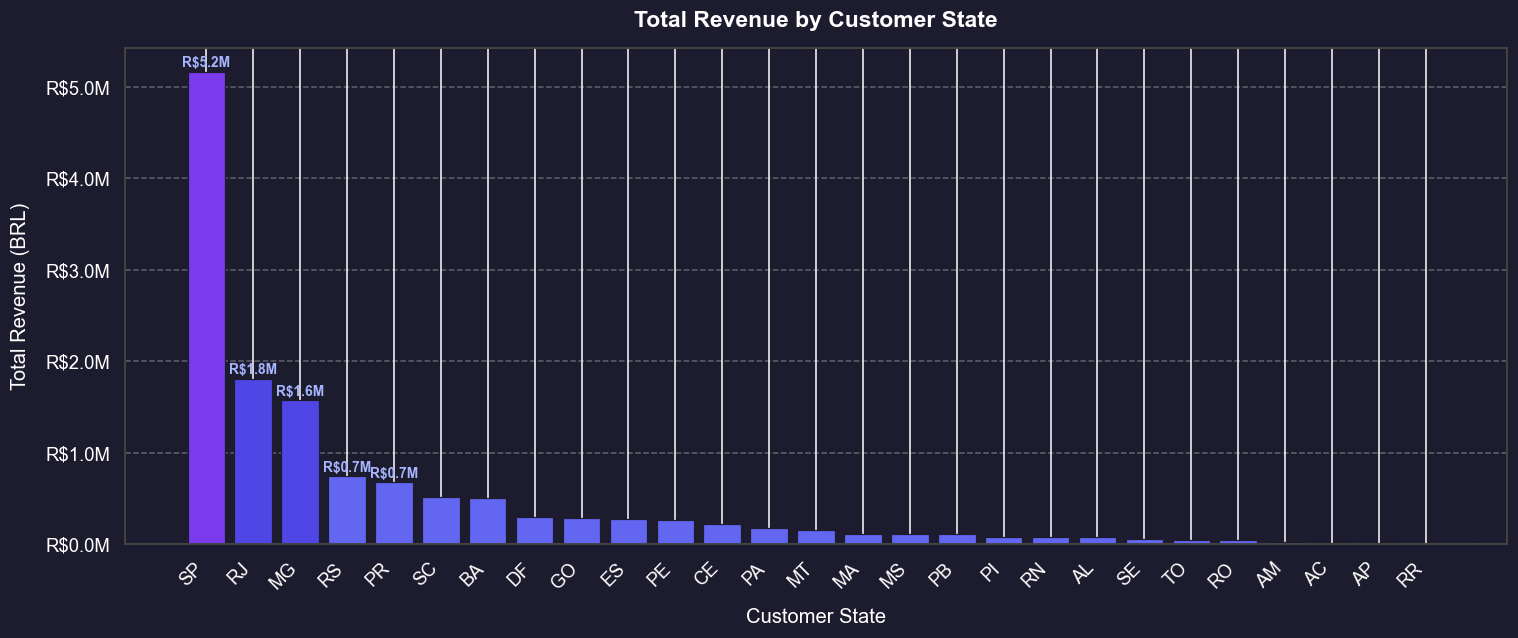

In [3]:
revenue_state = (
    df.groupby('customer_state')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
revenue_state.columns = ['State', 'Total Revenue (BRL)']
print(revenue_state.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = ['#7C3AED' if i == 0 else '#4F46E5' if i < 3 else '#6366F1'
              for i in range(len(revenue_state))]
bars = ax.bar(
    revenue_state['State'], revenue_state['Total Revenue (BRL)'],
    color=bar_colors, edgecolor=BG, linewidth=0.8
)
for bar, val in zip(bars[:5], revenue_state['Total Revenue (BRL)'][:5]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            f'R${val/1e6:.1f}M', ha='center', va='bottom',
            fontsize=9, color='#A5B4FC', fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_xlabel('Customer State', labelpad=10)
ax.set_ylabel('Total Revenue (BRL)', labelpad=10)
ax.set_title('Total Revenue by Customer State', fontsize=15, fontweight='bold', pad=14)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(INSIGHTS / 'eda_02_revenue_by_state.png', bbox_inches='tight', facecolor=BG)
plt.show()

> **Business Insight:** São Paulo (SP) alone accounts for ~42% of total GMV. Top 3 states (SP, RJ, MG) generate over 60% of revenue, revealing strong Southeast concentration risk. Northern states show minimal revenue and the longest delivery delays.

## 4 — Average Review Score by Product Category

In [4]:
category_reviews = (
    df.groupby('product_category_name_english')['review_score']
    .agg(avg_review_score='mean', order_count='count')
    .reset_index()
    .sort_values('avg_review_score', ascending=False)
)
category_reviews['avg_review_score'] = category_reviews['avg_review_score'].round(3)

print(f'Total categories: {len(category_reviews)}')
print(category_reviews[['product_category_name_english', 'avg_review_score', 'order_count']].to_string(index=False))

Total categories: 72
          product_category_name_english  avg_review_score  order_count
                      cds_dvds_musicals             4.667           12
                 books_general_interest             4.510          498
              fashion_childrens_clothes             4.429            7
                costruction_tools_tools             4.426           94
                             food_drink             4.399          223
                        books_technical             4.396          255
                                flowers             4.393           28
                                  music             4.389           36
                    luggage_accessories             4.345         1020
                         books_imported             4.321           53
                  arts_and_craftmanship             4.318           22
                          fashion_sport             4.308           26
  small_appliances_home_oven_and_coffee             4.29

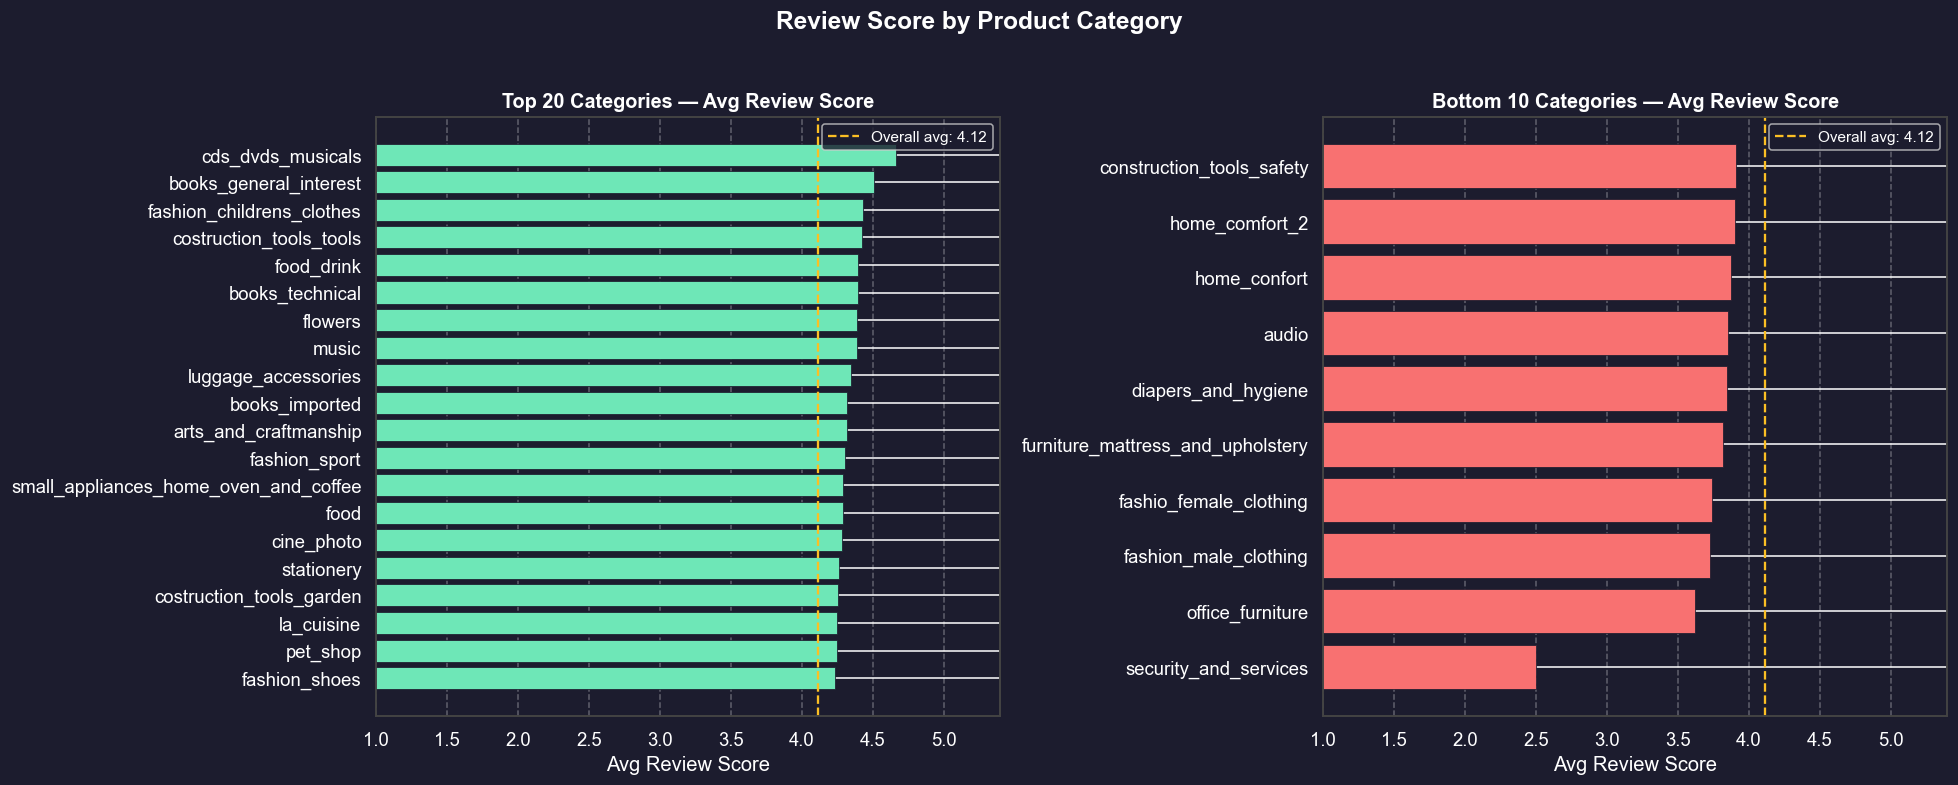

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
overall_avg = df['review_score'].mean()

for ax, data, title, color in [
    (axes[0], category_reviews.head(20), 'Top 20 Categories — Avg Review Score',    '#6EE7B7'),
    (axes[1], category_reviews.tail(10), 'Bottom 10 Categories — Avg Review Score', '#F87171'),
]:
    ax.barh(data['product_category_name_english'], data['avg_review_score'],
            color=color, edgecolor=BG, linewidth=0.5)
    ax.axvline(overall_avg, color='#FBBF24', linestyle='--',
               linewidth=1.5, label=f'Overall avg: {overall_avg:.2f}')
    ax.set_xlim(1, 5.4)
    ax.set_xlabel('Avg Review Score')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle('Review Score by Product Category', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(INSIGHTS / 'eda_03_review_by_category.png', bbox_inches='tight', facecolor=BG)
plt.show()

> **Business Insight:** Categories like `books_imported` score above 4.5, while `security_and_services` falls below 3.0. Low-scoring categories correlate with longer delivery delays or product quality issues.

## 5 — On-Time Delivery Rate by Product Category

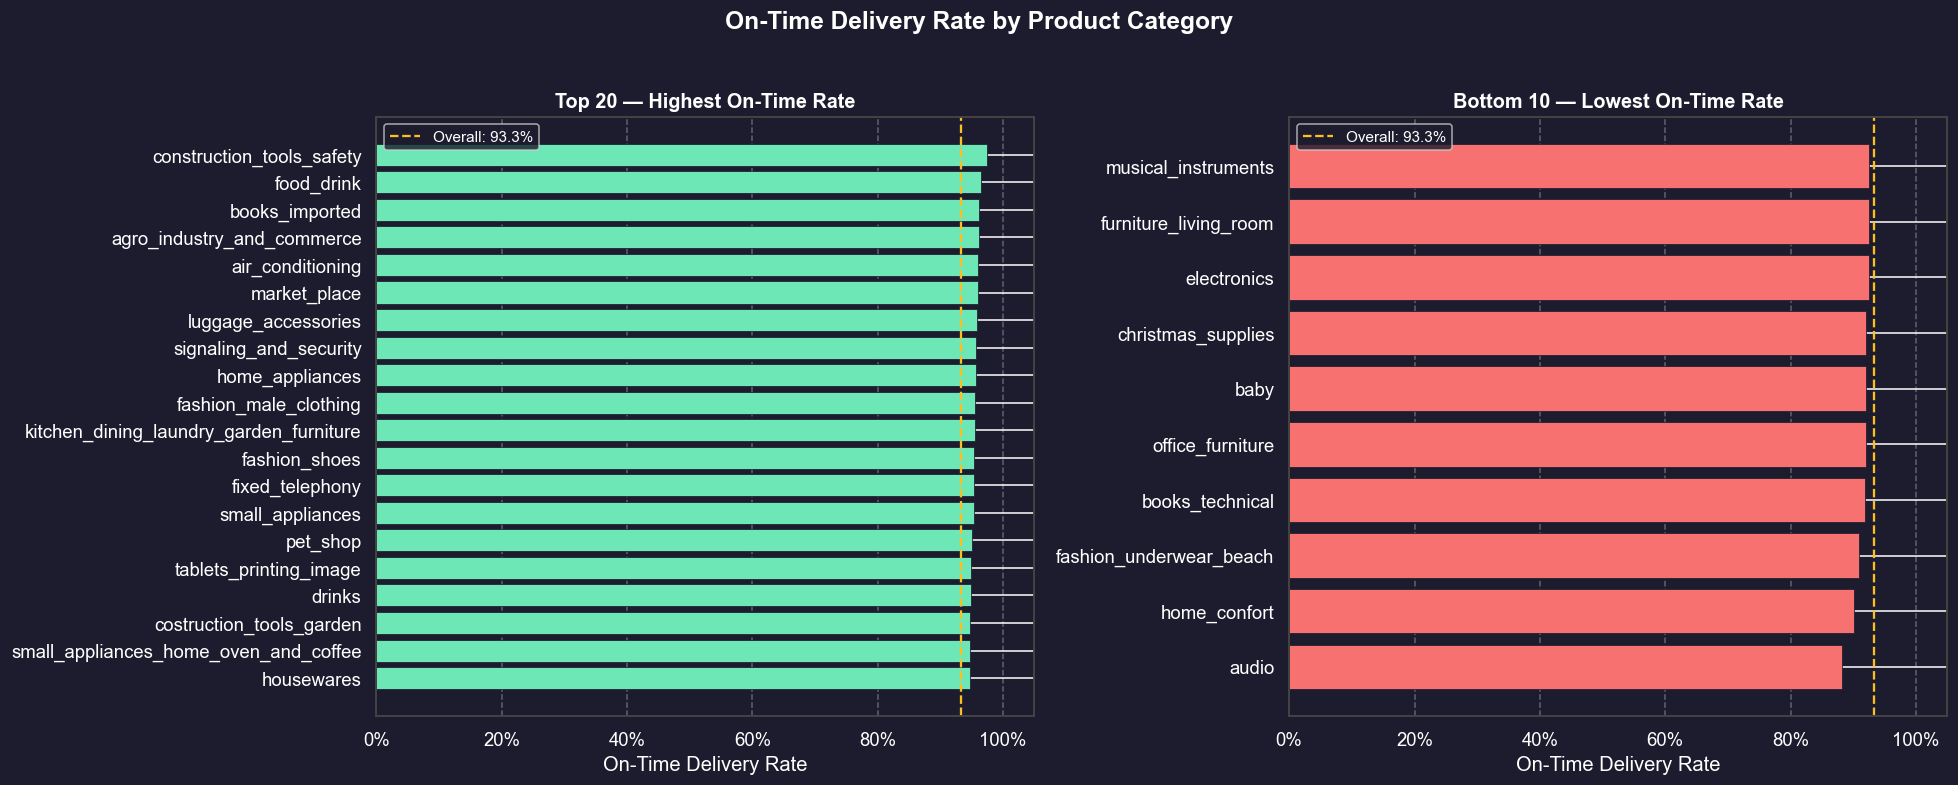

In [6]:
cat_ontime = (
    df[df['is_late'].notna()]
    .groupby('product_category_name_english')
    .agg(total=('order_id', 'count'), on_time=('is_late', lambda x: (x == False).sum()))
    .reset_index()
)
cat_ontime['on_time_rate'] = (cat_ontime['on_time'] / cat_ontime['total']).round(4)
cat_ontime = cat_ontime[cat_ontime['total'] >= 50].sort_values('on_time_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, title, color in [
    (axes[0], cat_ontime.head(20), 'Top 20 — Highest On-Time Rate',  '#6EE7B7'),
    (axes[1], cat_ontime.tail(10), 'Bottom 10 — Lowest On-Time Rate','#F87171'),
]:
    ax.barh(data['product_category_name_english'], data['on_time_rate'] * 100,
            color=color, edgecolor=BG, linewidth=0.5)
    ax.axvline(on_time_rate * 100, color='#FBBF24', linestyle='--',
               linewidth=1.5, label=f'Overall: {on_time_rate:.1%}')
    ax.set_xlim(0, 105)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xlabel('On-Time Delivery Rate')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle('On-Time Delivery Rate by Product Category', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(INSIGHTS / 'eda_04_ontime_by_category.png', bbox_inches='tight', facecolor=BG)
plt.show()

> **Business Insight:** Books and music ship near-100% on time from urban warehouses. Heavy goods like `furniture_mattress_and_upholstery` have the worst on-time records due to large-item logistics bottlenecks.